# Instruction-Tuning with Large Language Models (LLMs)

Instruction-based fine-tuning, commonly known as *Instruction GPT*, is a training approach where language models are optimized to understand and follow human instructions accurately. The objective is to help the model generate meaningful and task-specific responses based on user prompts.

In instruction-tuning, the dataset is highly important because it provides structured examples containing instructions, optional context, and expected outputs. By learning from these examples, the model becomes capable of handling a wide range of real-world tasks more effectively.

Many Instruction GPT systems are further improved using human feedback to refine response quality and alignment. However, this project focuses only on the instruction fine-tuning process and does not include reinforcement learning or human feedback optimization.

The instruction and context are typically merged into a single input sequence so the model can better understand the task and generate an appropriate response.

## Key Components

- **Instruction**  
  A task description or command that tells the model what action to perform.

- **Context**  
  Additional background information or supporting details required to complete the task correctly.

- **Combined Input**  
  The instruction and context are combined into one sequence before being passed to the model during training or inference.


### **Import Libraries**

In [1]:
import torch
import pickle
import io
import evaluate
import json
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset 
from torch.utils.data.dataset import Dataset
from urllib.request import urlopen
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import LoraConfig, TaskType, get_peft_model
import trl
from trl import SFTTrainer, SFTConfig
from transformers import  TrainingArguments



C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Load Dataset**

In [2]:
SEED = 42

In [3]:
dataset = load_dataset("sahil2801/CodeAlpaca-20k")

In [4]:
dataset.column_names

{'train': ['output', 'instruction', 'input']}

In [5]:
dataset['train'][1000]

{'output': 's = "Hello world" \ns = s[::-1] \nprint(s)',
 'instruction': 'Reverse the string given in the input',
 'input': 'Hello world'}

In [6]:
dataset = dataset['train']
dataset[1000]

{'output': 's = "Hello world" \ns = s[::-1] \nprint(s)',
 'instruction': 'Reverse the string given in the input',
 'input': 'Hello world'}

**Filter the Dataset Which Don't Have Any Input**

In [7]:
dataset = dataset.filter(lambda example: example['input'] == '')
dataset[0:2]

{'output': ['arr = [2, 4, 6, 8, 10]',
  'Height of triangle = opposite side length * sin (angle) / side length'],
 'instruction': ['Create an array of length 5 which contains all even numbers between 1 and 10.',
  'Formulate an equation to calculate the height of a triangle given the angle, side lengths and opposite side length.'],
 'input': ['', '']}

In [8]:
### shuffle the dataset
dataset = dataset.shuffle(seed=SEED)

In [9]:
dataset

Dataset({
    features: ['output', 'instruction', 'input'],
    num_rows: 9764
})

In [10]:
dataset['instruction'][0]

'Create a function that produces input strings for a calculator.'

**Split Dataset**

In [11]:
train_test_split = dataset.train_test_split(test_size=0.2,seed=SEED)
dataset_train = train_test_split['train']
dataset_test = train_test_split['test']
train_test_split

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 7811
    })
    test: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 1953
    })
})

### **Model & Tokenizer Implementation**

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m", padding_side = 'left')

In [14]:
tokenizer

GPT2Tokenizer(name_or_path='facebook/opt-350m', vocab_size=50265, model_max_length=1000000000000000019884624838656, padding_side='left', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, added_tokens_decoder={
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})

In [15]:
tokenizer.eos_token

'</s>'

In [16]:
model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m")
model.to(device)

Loading weights: 100%|██████████| 388/388 [00:00<00:00, 16865.72it/s]


OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear(in_features=1024, out_features=512, bias=False)
      (project_in): Linear(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=409

### Data Pre-Processing 

##### Formatting the prompt

In [17]:
def formatting_prompt_with_response (mydataset):
    response = []
    
    for i in range(len(mydataset)):
        text = (
            f"### Instruction: \n{mydataset['instruction'][i]}"
            f"\n\n ### Response: \n{mydataset['output'][i]}</s>"
        )
        
        response.append(text)
    return response

In [18]:
def formatting_prompt_without_response(mydataset):
    
    response = []
    
    for i in range(len(mydataset)):
        text = (
            f"### Instruction: \n{mydataset['instruction'][i]}"
            f"\n\n### Response:\n"
        )
        
        response.append(text)
    return response

In [19]:
tokenized_text = tokenizer("Hi I am vishwa", return_tensors="pt")
tokenized_text

{'input_ids': tensor([[    2, 30086,    38,   524,   748,  1173,  2739]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [20]:
tokenized_text['input_ids'][0]

tensor([    2, 30086,    38,   524,   748,  1173,  2739])

In [21]:
expected_outputs = []

instruction_with_response = formatting_prompt_with_response(dataset_test)
instruction_without_response = formatting_prompt_without_response(dataset_test)

for i in tqdm(range(len(instruction_with_response))):
    tokenized_instruction_with_response = tokenizer(instruction_with_response[i], return_tensors="pt")
    tokenized_instruction_without_response = tokenizer(instruction_without_response[i], return_tensors='pt')
    
    expected_output = tokenizer.decode(tokenized_instruction_with_response['input_ids'][0][len(tokenized_instruction_without_response['input_ids'][0])-1:],
                                       special_tokens = True)    
    expected_outputs.append(expected_output)
    

100%|██████████| 1953/1953 [00:02<00:00, 963.20it/s] 


In [22]:
instruction_without_response[0]

'### Instruction: \nName the most important benefit of using a database system.\n\n### Response:\n'

In [23]:
instruction_with_response[0]

'### Instruction: \nName the most important benefit of using a database system.\n\n ### Response: \nThe most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.</s>'

In [24]:
expected_outputs[0]

'\nThe most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.</s>'

# Converting Instructions into a PyTorch Dataset

Instead of keeping the instructions as a regular Python list, it is beneficial to convert them into a PyTorch `Dataset`. PyTorch models and training pipelines are designed to work efficiently with datasets that follow the `torch.utils.data.Dataset` structure.

To achieve this, a custom class called `ListDataset` is created by inheriting from `Dataset`. This class converts the `instructions` list into a dataset object that can be used directly in PyTorch workflows.

The `ListDataset` class typically implements:

- `__len__()` – Returns the total number of samples in the dataset.
- `__getitem__()` – Retrieves a specific sample using its index.

After converting the list into a `Dataset`, the data can be easily:

- Batched
- Shuffled
- Loaded efficiently with `DataLoader`
- Integrated into training and inference pipelines

This approach improves scalability, organization, and compatibility with industry-standard deep learning workflows in PyTorch.

In [25]:
class TemplateDataset(Dataset):
    
    def __init__(self, original_list):
        super().__init__()
        self.list = original_list
        
    def __len__(self):
        return len(self.list)

    def __getitem__(self, index):
        return self.list[index]

In [26]:
instructions = TemplateDataset(instruction_without_response)
instructions[0]

'### Instruction: \nName the most important benefit of using a database system.\n\n### Response:\n'

#### **Test Base Model Using Pipeline**

In [27]:
### define pipeline
pipeline_base_model = pipeline(task="text-generation",
                               model=model,
                               tokenizer=tokenizer,
                               batch_size = 2,
                               return_full_text = False)

In [28]:
with torch.no_grad():
    pipeline_iter = pipeline_base_model(instructions[:10], do_sample = True, temperature = 0.7, top_p =0.9,
                                        max_new_tokens = 100)

pipeline_iter

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_leng

[[{'generated_text': '\nThank you for your feedback.\n\n### How do you plan to use the data?\n\n### Will you have a backup of the data?\n\n### Will you have a backup of the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use'}],
 [{'generated_text': '\nThe only thing I can think of is to create a "string" that\'s like this:\n\n(string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string (string'}],
 [{'generated_text': '\nThe next step is to remove the last item from a list. The first step is to remove the last item from the list.\n\n### Response:\n\nThe next step is to remove the last item from the list. 

In [29]:
generate_text = []

for text in pipeline_iter:
    generate_text.append(text[0]['generated_text'])

In [30]:
generate_text[0]

'\nThank you for your feedback.\n\n### How do you plan to use the data?\n\n### Will you have a backup of the data?\n\n### Will you have a backup of the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use the data?\n\n### How do you plan to use'

In [31]:
url = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VvQRrSqS1P0_GobqtL-SKA/instruction-tuning-generated-outputs-base.pkl')

In [32]:
generated_texts = pickle.load(io.BytesIO(url.read()))

In [33]:
generated_texts[1]

'\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to solve an equation of the form ax + b = 0. Write corresponding code in Python.\n\n### Response:\n\n### Instruction:\nDescribe a method to

### **Model Evaluation (Pre-Taining Phase)**

# BLEU Score Evaluation

To evaluate the quality of generated responses against the expected (ground-truth) responses in the test environment, we use an automatic evaluation metric called the **BLEU score**.

BLEU (Bilingual Evaluation Understudy) is a metric originally designed to evaluate machine translation systems by measuring how closely a generated text matches one or more reference texts.

---

## How BLEU Score Works

The BLEU score compares:
- **Generated output (model prediction)**
- **Expected output (reference answer)**

It evaluates similarity based on overlapping n-grams (word sequences) between the two texts.

For each sample, a BLEU score is computed individually, and the final score is obtained by averaging across all test samples.

---

## Score Range

Depending on implementation, BLEU scores are expressed in:

- **0 to 1** (standard form), or  
- **0 to 100** (scaled version used in many implementations)

A **higher BLEU score indicates better alignment** between the generated output and the expected response.

---

## Important Notes

1. **Original Purpose**
   
   BLEU was originally designed for machine translation tasks. While it is commonly used in NLP evaluation, it may not always fully capture the quality of instruction-tuned language models. However, it still provides a useful signal for comparing generated outputs with reference answers.

---

2. **Metric Variability**

   BLEU is a **parametrized metric**, meaning its results can vary depending on:
   - n-gram size
   - smoothing techniques
   - tokenization rules

   Because of this, BLEU scores may not be directly comparable across different studies or implementations.

   To address this issue, a standardized version called **SacreBLEU** is often used. It ensures consistent evaluation by fixing the metric configuration.

   Learn more: https://aclanthology.org/W18-6319/

---

3. **Experimental Variation**

   Slight differences in BLEU scores may occur due to:
   - model randomness
   - tokenization differences
   - evaluation setup variations

   This is normal and expected when evaluating generative models.

---

## Summary

BLEU provides a fast and simple way to measure overlap between generated and expected text, making it useful for:
- baseline evaluation
- model comparison
- tracking training improvements

However, it should ideally be used alongside other evaluation methods for a more complete assessment of model quality.

In [34]:
sacrebleu_matrix = evaluate.load("sacrebleu")

results_matrix = sacrebleu_matrix.compute(predictions=generated_texts, references=expected_outputs)


In [35]:
results_matrix

{'score': 0.009296734954133449,
 'counts': [6353, 123, 5, 1],
 'totals': [481137, 479199, 477262, 475325],
 'precisions': [1.3204139361553986,
  0.025667833196646905,
  0.0010476425946335556,
  0.00021038236995739757],
 'bp': 1.0,
 'sys_len': 481137,
 'ref_len': 118330}

In [36]:
print(list(results_matrix.keys()))
print(round(results_matrix["score"], 1))

['score', 'counts', 'totals', 'precisions', 'bp', 'sys_len', 'ref_len']
0.0


In [37]:
print(f"number of model parameters: { sum(param.numel() for param in model.parameters())}")

number of model parameters: 331196416


### **Model Training**

To save time, we can perform instruction fine-tuning using a parameter-efficient fine-tuning (PEFT) technique known as Low-Rank Adaptation (LoRA).

First, we transform the base model into a PEFT-compatible model by creating a LoraConfig object from the peft library, where we specify key LoRA settings such as the rank and the target layers to be adapted. After defining this configuration, we apply it to the model using get_peft_model(), which converts the original model into a LoRA-enhanced version ready for efficient fine-tuning.

In [38]:
lora_config = LoraConfig(
    task_type= TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    target_modules=['q_proj', 'v_proj'],
    lora_dropout=0.1
)

In [39]:
## define peft model
peft_model = get_peft_model(model, lora_config)

W0517 09:17:59.949000 18372 torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


#### **Define Supervised Fine-Tune (SFT)**

In [40]:
response_template = "### Response:"
collator = DataCollatorForCompletionOnlyLM(
    response_template=response_template, 
    tokenizer = tokenizer,
)

NameError: name 'DataCollatorForCompletionOnlyLM' is not defined

In [ ]:
trainer_config = TrainingArguments(
    output_dir="/traing_dir",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    num_train_epochs=5,
    save_strategy="epoch",
    fp16=True,
    weight_decay=0.1,
    eval_strategy="epoch"
)

In [ ]:
trainer = SFTTrainer(
     model=peft_model,
    args=trainer_config,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    data_collator=collator,
    tokenizer=tokenizer,          
    formatting_func=formatting_prompt_with_response,
    
)

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\trl\trainer\sft_trainer.py:246: UserWarning: You didn't pass a `max_seq_length` argument to the SFTTrainer, this will default to 1024
  warnings.warn(
Map: 100%|██████████| 1953/1953 [00:00<00:00, 48829.41 examples/s]
C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\trl\trainer\sft_trainer.py:318: UserWarning: You passed a tokenizer with `padding_side` not equal to `right` to the SFTTrainer. This might lead to some unexpected behaviour due to overflow issues when training a model in half-precision. You might consider adding `tokenizer.padding_side = 'right'` to your code.
  warnings.warn(


TypeError: Trainer.__init__() got an unexpected keyword argument 'tokenizer'

### **Based on version conflicts of TRL and TRANSFORMERS libraries the SFT trainer does not support tokenizer anymore and trl does not support DataCollatorForCompletionOnlyLM anymore.** 

we need to move on the latest industrial practices

In [41]:
def format_as_chat(mydataset):
    
    text = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content" : mydataset['instruction']},
        {"role": "assistant", "content": mydataset['output']},
    
    ]
    return {"message": text}

In [42]:
dataset_new = load_dataset("sahil2801/CodeAlpaca-20k")

In [43]:
dataset_new

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 20022
    })
})

In [44]:
dataset_new = dataset_new.map(format_as_chat)

In [45]:
dataset_new['train'][0]['message']

[{'content': 'You are a helpful assistant.', 'role': 'system'},
 {'content': 'Create an array of length 5 which contains all even numbers between 1 and 10.',
  'role': 'user'},
 {'content': 'arr = [2, 4, 6, 8, 10]', 'role': 'assistant'}]

In [46]:
dataset_new

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input', 'message'],
        num_rows: 20022
    })
})

In [47]:
new_train_test_split = dataset_new['train'].train_test_split(test_size=0.1, seed=SEED)

In [48]:
new_train_dataset = new_train_test_split['train']
new_test_dataset = new_train_test_split['test']

In [49]:
new_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1")

### **SFT Configuration**

In [50]:
sft_config = SFTConfig(
    output_dir="./train_dir",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    learning_rate=1e-4,
    weight_decay=0.1,
    save_strategy="epoch",
    eval_strategy='epoch',
    max_length=1024,
    dataset_text_field="message",
    warmup_steps=5,
)

In [51]:
sft_trainer = SFTTrainer(
    model=peft_model,
    train_dataset=new_train_dataset,
    eval_dataset=new_test_dataset,
    args=sft_config, 
    processing_class= new_tokenizer
)

**The Model Training is a very time cosuming with normal cpu environment, so that we use the cloud data which the model has trained to nearly 300 epochs**

In [ ]:
sft_trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 1, 'pad_token_id': 2}.


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

You can load the generated texts for the entire dataset from the fine-tuned LoRA model and run on GPU.


In [55]:
url = urlopen("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/49I70jQD0-RNRg2v-eOoxg/instruction-tuning-log-history-lora.json")
log_history = json.load(io.BytesIO(url.read()))

In [58]:
log_history[0]

{'loss': 1.964,
 'grad_norm': 3.12174391746521,
 'learning_rate': 4.936251920122888e-05,
 'epoch': 0.12800819252432155,
 'step': 500}

### Plot the Outcomes

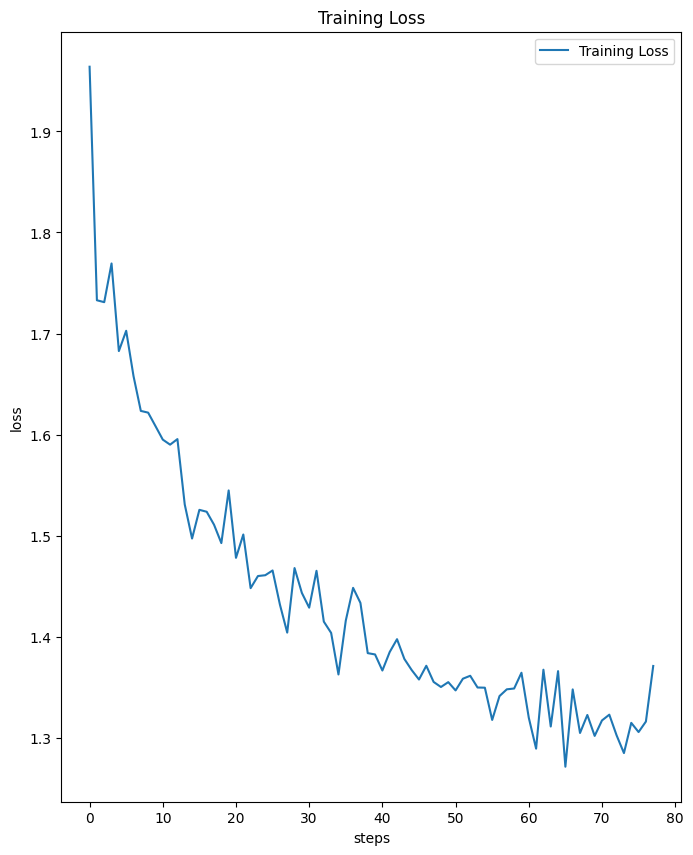

In [59]:
train_loss = [log['loss'] for log in log_history if "loss" in log]

plt.figure(figsize=(8,10))
plt.plot(train_loss, label = "Training Loss")

plt.xlabel("steps")
plt.ylabel("loss")
plt.title("Training Loss")

plt.legend()
plt.show()

**Generate Texts with Fine-Tunes Peft Model**

In [60]:
get_lora_pipeline = pipeline(
    task="text-generation",
    model = peft_model,
    tokenizer = new_tokenizer,
    device = device,
    batch_size =2,
)

In [62]:
with torch.no_grad():
    
    peft_pipeline_iter = get_lora_pipeline(instructions[0:10],
                                           num_beams = 5,
                                           early_stopping =True )


[transformers] Passing `generation_config` together with generation-related arguments=({'early_stopping', 'num_beams', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in OPTDecoderLayer. Setting `past_key_values=None`.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips space

In [63]:
peft_pipeline_iter

[[{'generated_text': '### Instruction: \nName the most important benefit of using a database system.\n\n### Response:\nName sounds'}],
 [{'generated_text': '### Instruction: \nCome up with a Java program that checks if one string is a substring of another.\n\n### Response:\n Statesb createfgWWeyeyther� reports normalWWeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyey\x05\x05\x05\x1b\x1b The The����eyeyeyeyeyeyeyeyey\x03\x0eeyeyeyey OR ORlleyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyey\t\x0e\x0e\x0eofeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyleyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyeyWWWWWWWW\x01\x0e\x0e\x0e\x0eeyeyeyey\x0e\x0e\x0e'}],
 [{'generated_text': '### Instruction: \nHow do you remove the last item from a list in Python?\n\n### Response:\nHow\x032,=\x0e\x18\x1a span\x01'}],
 [{'generated_text': '### Instruction: \nCreate a SQL table with the following schema: id (integer), name (string), city (string).\n\n### Response:\n������eyeyeyeyeyeyeyeyeyeyeyeyeye

In [64]:
peft_generated_texts = []
for txt in peft_pipeline_iter:
    peft_generated_texts.append(txt[0]['generated_text'])

peft_generated_texts[0]

'### Instruction: \nName the most important benefit of using a database system.\n\n### Response:\nName sounds'

You can load the generated texts for the entire dataset from the fine-tuned LoRA model and run on GPU.


In [65]:
url = urlopen("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/o7uYxe15xvX4CN-6Lr10iA/instruction-tuning-generated-outputs-lora.pkl")
generated_texts_peft = pickle.load(io.BytesIO(url.read()))